# Churn at Fit.ly Tech
Cree Smithers

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_palette(palette = 'crest')
import matplotlib.pyplot as plt
print('loaded!')

loaded!


In [2]:
# load all 3 files
user_activity = pd.read_csv('da_fitly_user_activity.csv')
cs = pd.read_csv('da_fitly_customer_support.csv')
account_info = pd.read_csv('da_fitly_account_info.csv')

In [3]:
print(user_activity.head())
print(user_activity['event_type'])
print(user_activity.dtypes)
    # event time    user_id    event_type
print(cs.head())
    # ticket_time    user_id    channel    topic    resolution_time_hours    state  comments
print(cs.dtypes)
print(cs['topic'].unique())
print(account_info.head())
    # customer_id    email    state    plan    plan_list_price    churn_status
print(account_info.dtypes)
#print(account_info['email'].unique())

                   event_time  user_id     event_type
0  2025-09-08 15:05:39.422721    10118    watch_video
1  2025-09-08 08:15:05.264103    10220    watch_video
2  2025-11-14 06:28:35.207671    10009  share_workout
3  2025-08-20 16:53:38.682901    10227   read_article
4  2025-07-24 16:47:31.728422    10123  track_workout
0        watch_video
1        watch_video
2      share_workout
3       read_article
4      track_workout
           ...      
440     read_article
441      watch_video
442    track_workout
443    track_workout
444    share_workout
Name: event_type, Length: 445, dtype: object
event_time    object
user_id        int64
event_type    object
dtype: object
                  ticket_time  user_id  ... state                          comments
0  2025-06-13 05:55:17.154573    10125  ...     1                               NaN
1  2025-08-06 13:21:54.539551    10109  ...     0                               NaN
2  2025-08-22 12:39:35.718663    10149  ...     0  Erase my data from y

In [4]:
# user_id for account info is labeled as customer_id and has a leading C
# remove leading C, convert type to float64 to match User Activity and Customer Support tickets
account_info['customer_id'] = account_info['customer_id'].str.lstrip('C').astype('float64')

# rename for ease of merging
account_info = account_info.rename(columns = {'customer_id': 'user_id'})

---
---
# Validation

In [5]:
# CUSTOMER SUPPORT VALIDATION
# ticket_time    user_id    channel    topic    resolution_time_hours    state  comments

# ticket_time
    # object --> convert to date_time
cs['ticket_time'] = pd.to_datetime(cs['ticket_time'])

    # check earliest and latest ticket_time, no issues here
print(cs['ticket_time'].min())
print(cs['ticket_time'].max())

print([cs['ticket_time'].isna().sum()])
    # no NaN data

cs['ticket_time'].duplicated().sum()
    # no duplicates

    ### no more work needed



# user_id
    # 367 unique out of 918 total - so a lot of multiples
print('user_id shape: ', cs['user_id'].shape)
print(len(cs['user_id'].unique()))



# channel validation
    # cs channels: chat, phone, -, email
    # 39 blanks out of 918
cs['channel'] = cs['channel'].replace('-', 'unknown')

# topic
    # technical, account, other, billing
    ### no work needed

# resolution_time
print(cs['resolution_time_hours'].describe())
    # min .5    max 32.4    nothing below 0    all 918
    ### no work needed

# state
    # 1 and 0
    # Sasha said in account_info we're not worried about it right now so remove for this analysis
print('unique state values: ', cs['state'].unique())
cs = cs.drop('state', axis = 1)

    ### no more work needed

# comments
    # many have right to delete requests - delete below
print(cs[~cs['comments'].isna()].head())

    # data deleted
cs = cs[cs['comments'].isna()]


# DONE
    # changed ticket time to datetime
    # Dropped State
    # replace '-' for 'unknown' for channel information
    # Complied with Right to Delete requests and Dropped those customers


# Notes
    # states were just 1s and 0s
    # Data Engineer will need to drop the customers from Database

2025-06-05 15:32:33.005817
2025-12-01 22:01:58.485299
[0]
user_id shape:  (918,)
367
count    918.000000
mean      10.391362
std        7.079888
min        0.520000
25%        5.112500
50%        9.040000
75%       13.137500
max       32.460000
Name: resolution_time_hours, dtype: float64
unique state values:  [1 0]
                   ticket_time  ...                              comments
2   2025-08-22 12:39:35.718663  ...      Erase my data from your systems.
32  2025-07-15 09:40:42.631879  ...  Request full personal data deletion.
39  2025-10-06 13:36:20.025866  ...               Wipe all data you hold.
76  2025-10-13 11:06:37.711703  ...          Please erase my information.
103 2025-11-23 09:41:03.346021  ...          Please erase my information.

[5 rows x 6 columns]


In [6]:
# USER ACTIVITY VALIDATION
print(user_activity.shape)
# event time    
    # object --> datetime
user_activity['event_time'] = pd.to_datetime(user_activity['event_time'])

    # check earliest and latest time - no issues
print(user_activity['event_time'].min())
print(user_activity['event_time'].max())

print([user_activity['event_time'].isna().sum()])
    # no NaN data


# user_id    
print(user_activity['user_id'].shape)
print(len(user_activity['user_id'].unique()))
    # there are doubles! but that's expected


# event_type
print(user_activity['event_type'].value_counts())
    # watch_video, share_workout, read_article, track_workout
    # I don't think any work is needed


# DONE
    # changed event_time object to datetime

# TO DO
    # none

# Notes

(445, 3)
2025-06-05 10:14:53.039663
2025-12-01 21:12:13.342817
[0]
(445,)
246
read_article     125
watch_video      120
track_workout    108
share_workout     92
Name: event_type, dtype: int64


The first step in validation was to ensure our User IDs matched. Our account info had a leading 'C' for their customer ID so that was stripped and converted to an integer. I renamed the column to User ID for ease of use. 

Next I went column by column in each dataframe. 

**Customer Support Columns:** 
1. Ticket_time: This was changed from an object to datetime and verified that date or time didn't have any oddities like being in the future or before the last 2 quarters of 2025. 
2. User_id: No work needed. 
3. Channel: Changed channel from '-' to 'unknown.' The other 3 were phone, chat, and email.
4. Topic: No work needed. Topics were: technical, account, other, and billing. 
5. Resolution Time in Hours: No work needed. Verified no negative times and data is type float64
6. State: Only comes in 0s and 1s. Dropped for this analysis as Sasha said we weren't worried about it in the Account Info sections
7. Comments: Many comments asking for deletion of data. They were removed before any analysis. Data Engineer needs to remove from database.

**User Activity Columns:**
1. Event_time: Changed from an object to datetime and verified that date or time had no oddities like being in the future or before last 2 quarters of 2025. 
2. User_id: No work needed. Type of Int64
3. Event_type: No work needed. Values were: watch_video, share_workout, track_workout, read_article. 

**Account Info Columns:** 
1. Customer_id: as mentioned above the leading 'C' was removed and column renamed to 'user_id'
2. Email: Dropped for analysis. Something to note is they all appear to be placeholders of the form "user10080@example.com"
3. State: Dropped as Sasha said we're not tracking. No weird data here: all 50 states present.
4. Plan: All free users are indeed paying $0. Free plans were left out for correlations with churn. 
5. Plan_list_price: No work was needed. Free plans were left out for correlations with churn. Datatype int64
6. Churn_status: Changed from 'Y' to 1 for churned and from NaN to 0 for not-churned.


**Other Information of Note:**
- Signup_date column is not present. Sasha (Product manager) mentioned it in the Account Info data and would be something to follow up on.
- Nicole (lead engineer) says datasets get updated daily but there were rights to delete info in the dataframes. There should be an automated process to check for those daily. 


In [7]:
# ACCOUNT INFO VALIDATION
print(account_info.shape)
# customer_id


# email    
print(account_info['email'].iloc[0])
account_info = account_info.drop('email', axis = 1)

# state    
#print(len(account_info['state'].unique()))
    # 50 states, as Sasha said we're not tracking but nothing weird here

# plan    
print(account_info['plan'].unique())
    # free, basic, pro, enterprise - just like Sasha said
    ### no more work needed

# plan_list_price    
print(account_info['plan_list_price'].describe())
    # min - 0 for Free    max 148    type float64    nothing odd   
    ### no more work needed


# churn_status
#print(account_info['churn_status'].unique())
    # Y and NaN
account_info['churn_status'] = account_info['churn_status'].map({'Y': 1}).fillna(0).astype(int)


# DONE
    # Changed churn status to 1: churned, 0: not churned

# TO DO
    # delete email? there's only example emails

# Notes
    # Missing signup_date info
    # emails all of format [user10000@example.com]

print(account_info.columns)

(400, 6)
user10000@example.com
['Enterprise' 'Basic' 'Free' 'Pro']
count    400.000000
mean      43.965000
std       45.263348
min        0.000000
25%        0.000000
50%       26.000000
75%       77.250000
max      148.000000
Name: plan_list_price, dtype: float64
Index(['user_id', 'state', 'plan', 'plan_list_price', 'churn_status'], dtype='object')


In [8]:
# MISSING DATA DOUBLE CHECK

print(cs.isna().sum())
    # comments missing from 872, nothing to worry about. 
print(account_info.isna().sum())
print(user_activity.isna().sum())

ticket_time                0
user_id                    0
channel                    0
topic                      0
resolution_time_hours      0
comments                 872
dtype: int64
user_id            0
state              0
plan               0
plan_list_price    0
churn_status       0
dtype: int64
event_time    0
user_id       0
event_type    0
dtype: int64


---
---
# Exploratory Analysis

In [9]:
print('customer_support columns: ', cs.columns)
print('account_info columns: ', account_info.columns)
print('user_activity columns: ', user_activity.columns)

customer_support columns:  Index(['ticket_time', 'user_id', 'channel', 'topic', 'resolution_time_hours',
       'comments'],
      dtype='object')
account_info columns:  Index(['user_id', 'state', 'plan', 'plan_list_price', 'churn_status'], dtype='object')
user_activity columns:  Index(['event_time', 'user_id', 'event_type'], dtype='object')


In [10]:
# create copy for analysis
base_df = account_info.copy()

# 
cs_agg = (
    cs.groupby('user_id').agg(
        cs_ticket_count = ('ticket_time', 'count'),
        cs_avg_resolution_hours = ('resolution_time_hours', 'mean'),
        cs_max_resolution_hours = ('resolution_time_hours', 'max'),
        ).reset_index()
)

# merge together
cs_df = base_df.merge(cs_agg, on = 'user_id', how = 'left')
cs_df['cs_ticket_count'] = cs_df['cs_ticket_count'].fillna(0)


# add topics and channels
topic_dummies = pd.get_dummies(cs[['user_id', 'topic']], prefix = 'topic')
topic_agg = (topic_dummies.groupby('user_id').sum()
            .reset_index())
channel_dummies = pd.get_dummies(cs[['user_id', 'channel']], prefix = 'channel')
channel_agg = (channel_dummies.groupby('user_id').sum()
              .reset_index())
cs_df = cs_df.merge(topic_agg, on = 'user_id', how = 'left')
cs_df = cs_df.merge(channel_agg, on = 'user_id', how = 'left')

topic_cols = [c for c in cs_df.columns if c.startswith('topic_')]
channel_cols = [c for c in cs_df.columns if c.startswith('channel_')]

cs_df[topic_cols + channel_cols] = cs_df[topic_cols + channel_cols].fillna(0)

print(cs_df.head())

   user_id       state  ... channel_phone  channel_unknown
0  10000.0  New Jersey  ...           0.0              0.0
1  10001.0   Louisiana  ...           3.0              0.0
2  10002.0    Oklahoma  ...           0.0              0.0
3  10003.0    Michigan  ...           0.0              1.0
4  10004.0       Texas  ...           1.0              1.0

[5 rows x 16 columns]


In [11]:
#activity agg
activity_agg = (
    user_activity.groupby('user_id').agg(
        total_activities = ('event_time', 'count'), 
        last_activity_time = ('event_time', 'max'),
        ).reset_index()
    )

#merge
act_df = base_df.merge(activity_agg, on = 'user_id', how = 'left')

# days since last event
act_df['days_since_activity'] = (act_df['last_activity_time'].max() - act_df['last_activity_time']).dt.days

# add in event types
event_agg = (
    user_activity.groupby(['user_id', 'event_type'])
    .size()
    .unstack(fill_value = 0)
    .reset_index()
)
# merge to act_df
act_df = act_df.merge(event_agg, on ='user_id', how = 'left')

# fill NaNs 
act_cols = ['share_workout', 'track_workout', 'watch_video', 'read_article']
act_df[act_cols] = act_df[act_cols].fillna(0)
act_df['did_activity'] = (act_df[act_cols].sum(axis=1)>0).astype(int)
print(act_df)

     user_id       state        plan  ...  track_workout  watch_video  did_activity
0    10000.0  New Jersey  Enterprise  ...            0.0          1.0             1
1    10001.0   Louisiana       Basic  ...            0.0          0.0             1
2    10002.0    Oklahoma       Basic  ...            0.0          0.0             1
3    10003.0    Michigan        Free  ...            1.0          0.0             1
4    10004.0       Texas  Enterprise  ...            1.0          3.0             1
..       ...         ...         ...  ...            ...          ...           ...
395  10395.0     Arizona        Free  ...            0.0          0.0             1
396  10396.0     Vermont        Free  ...            0.0          0.0             1
397  10397.0     Vermont        Free  ...            0.0          0.0             0
398  10398.0     Alabama  Enterprise  ...            0.0          0.0             0
399  10399.0  California        Free  ...            0.0          0.0       

In [12]:
print(cs_df.dtypes)
print('---')
print(act_df.dtypes)

user_id                    float64
state                       object
plan                        object
plan_list_price              int64
churn_status                 int64
cs_ticket_count            float64
cs_avg_resolution_hours    float64
cs_max_resolution_hours    float64
topic_account              float64
topic_billing              float64
topic_other                float64
topic_technical            float64
channel_chat               float64
channel_email              float64
channel_phone              float64
channel_unknown            float64
dtype: object
---
user_id                       float64
state                          object
plan                           object
plan_list_price                 int64
churn_status                    int64
total_activities              float64
last_activity_time     datetime64[ns]
days_since_activity           float64
read_article                  float64
share_workout                 float64
track_workout                 float64
watc

In [13]:
# analysis on paying members churn rates
paying_cs = cs_df[cs_df['plan'] != 'Free']
paying_act = act_df[act_df['plan'] != 'Free']
print(paying_cs.columns)
print(paying_act.columns)

Index(['user_id', 'state', 'plan', 'plan_list_price', 'churn_status',
       'cs_ticket_count', 'cs_avg_resolution_hours', 'cs_max_resolution_hours',
       'topic_account', 'topic_billing', 'topic_other', 'topic_technical',
       'channel_chat', 'channel_email', 'channel_phone', 'channel_unknown'],
      dtype='object')
Index(['user_id', 'state', 'plan', 'plan_list_price', 'churn_status',
       'total_activities', 'last_activity_time', 'days_since_activity',
       'read_article', 'share_workout', 'track_workout', 'watch_video',
       'did_activity'],
      dtype='object')


First visual to look at is Customer Support Tickets. 
No users have more than 7 and very few reach a total of 5 support tickets. 
We have no users with massive number of tickets skewing the data. 

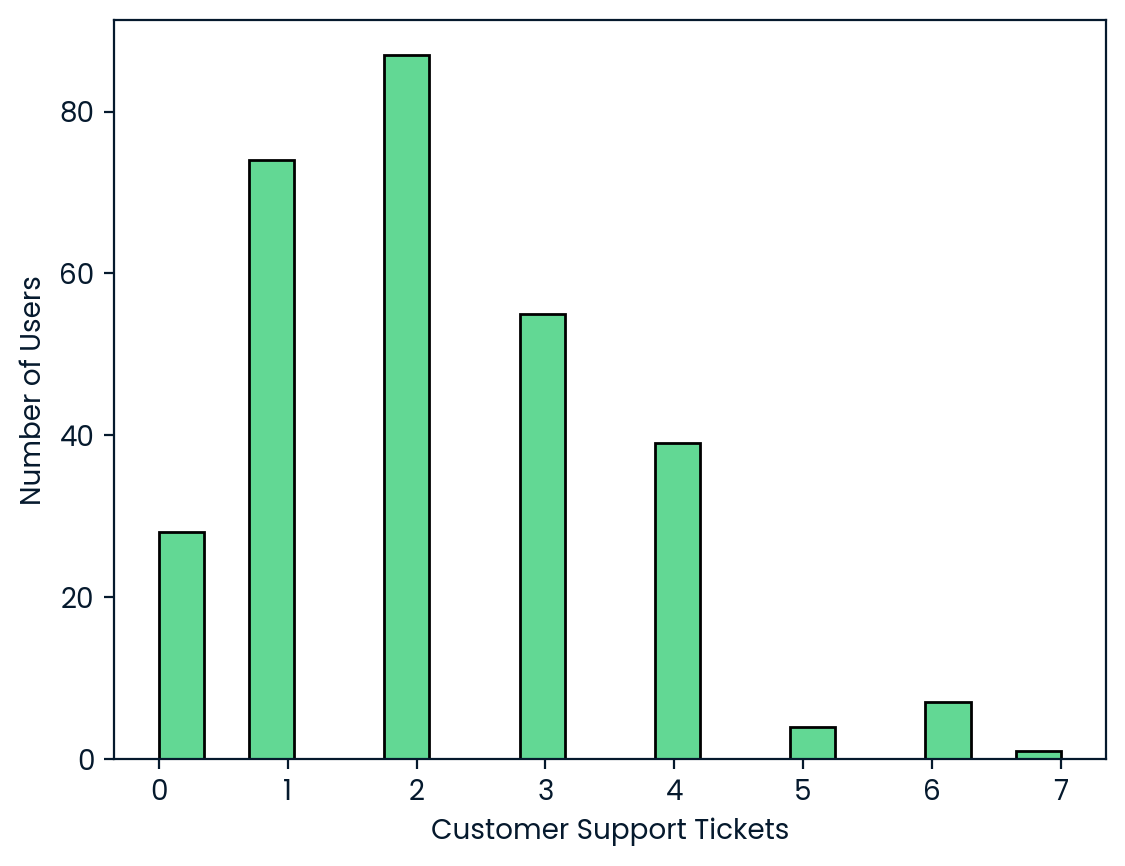

In [14]:
sns.histplot(paying_cs['cs_ticket_count'], bins = 20, color = '#2ECC71')
plt.xlabel('Customer Support Tickets')
plt.ylabel('Number of Users')
plt.show()

Another visual here we see no large difference between count of people who never logged an activity and those who logged at least one. 

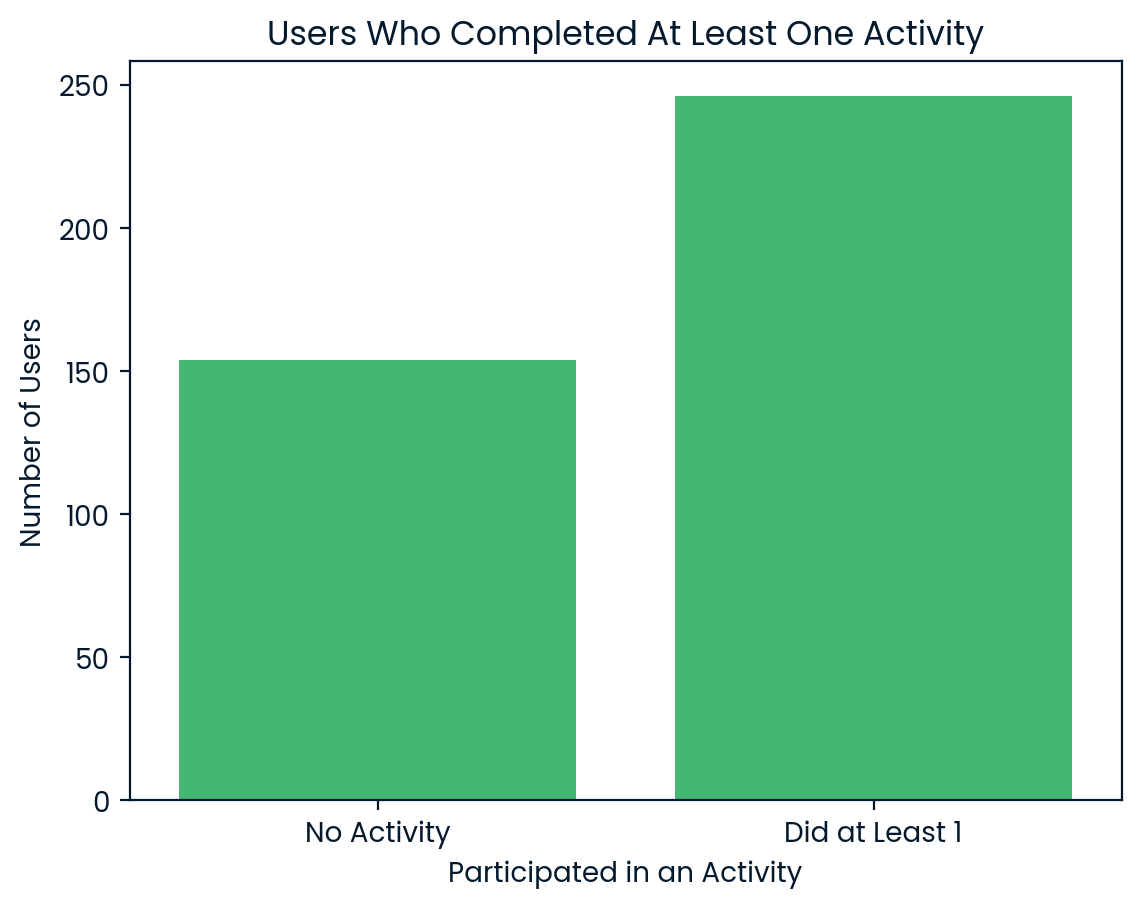

In [15]:
sns.countplot(x = 'did_activity', data = act_df, color = '#2ECC71')
plt.xticks([0,1], ['No Activity', 'Did at Least 1'])
plt.xlabel('Participated in an Activity')
plt.ylabel('Number of Users')
plt.title('Users Who Completed At Least One Activity')
plt.show()

A lot was learned through graphics with multiple variables and seeing the relationship between the two. I'll print all of them and summarize at the bottom. 

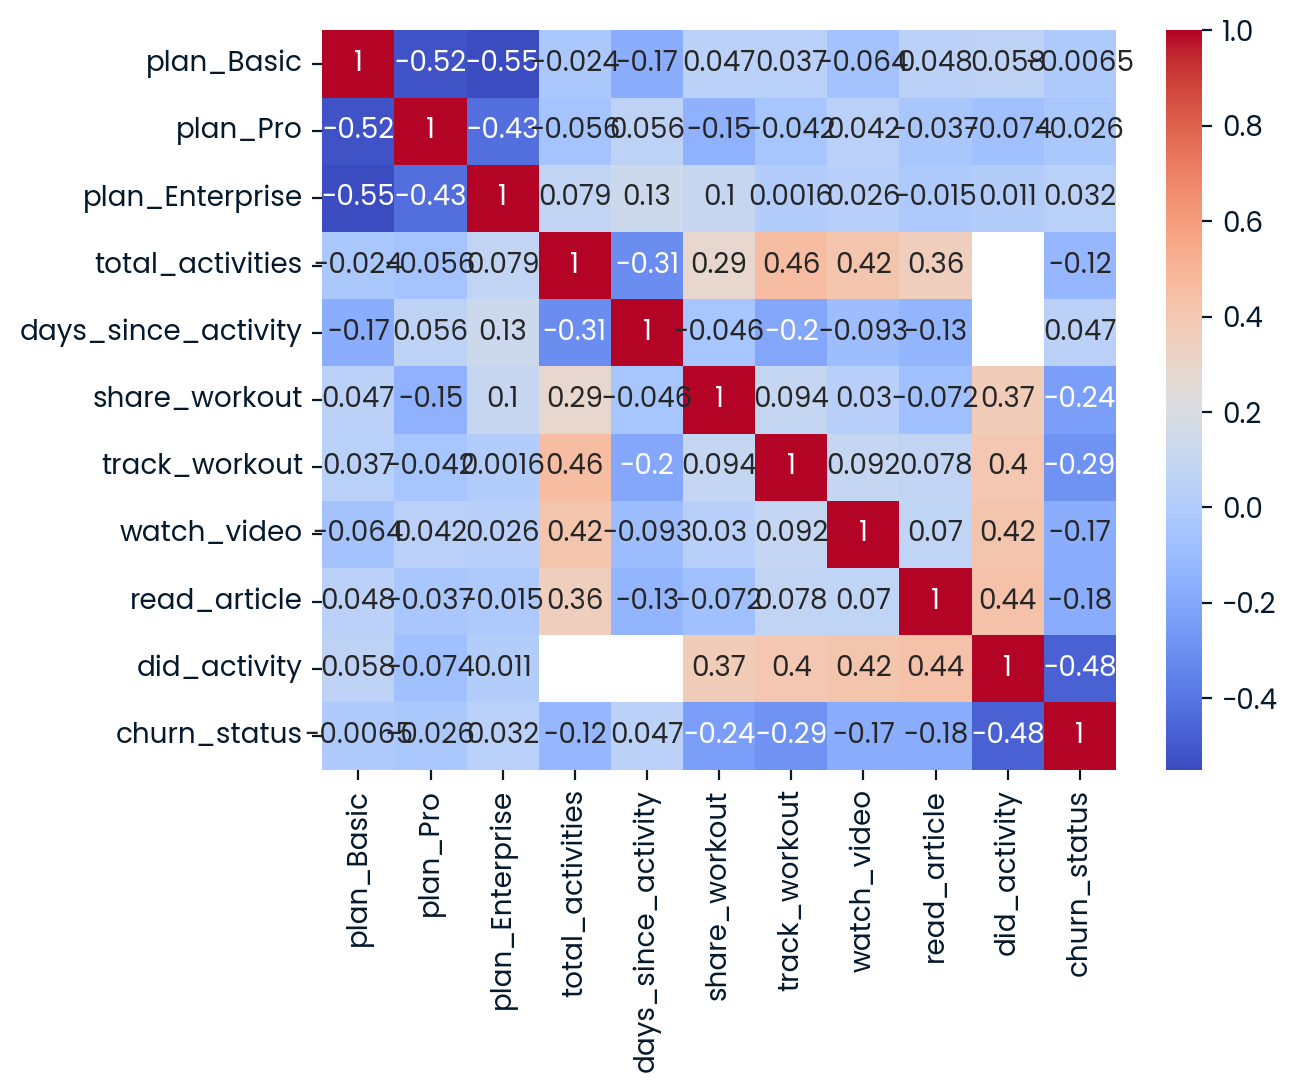

In [16]:
# activity heatmap (including plan)
plan_order = {'Free': 0, 'Basic': 1, 'Pro': 2, 'Premium': 3}
paying_act['plan_num'] = paying_act['plan'].map(plan_order)

plan_dummies = pd.get_dummies(paying_act['plan'], prefix='plan')
paying_act = paying_act.merge(plan_dummies, left_index=True, right_index=True)

act_corr = paying_act[['plan_Basic', 'plan_Pro', 'plan_Enterprise', 'total_activities', 'days_since_activity', 'share_workout', 'track_workout', 'watch_video', 'read_article', 'did_activity', 'churn_status',]].corr()
sns.heatmap(act_corr, annot = True, cmap = 'coolwarm')
plt.show()

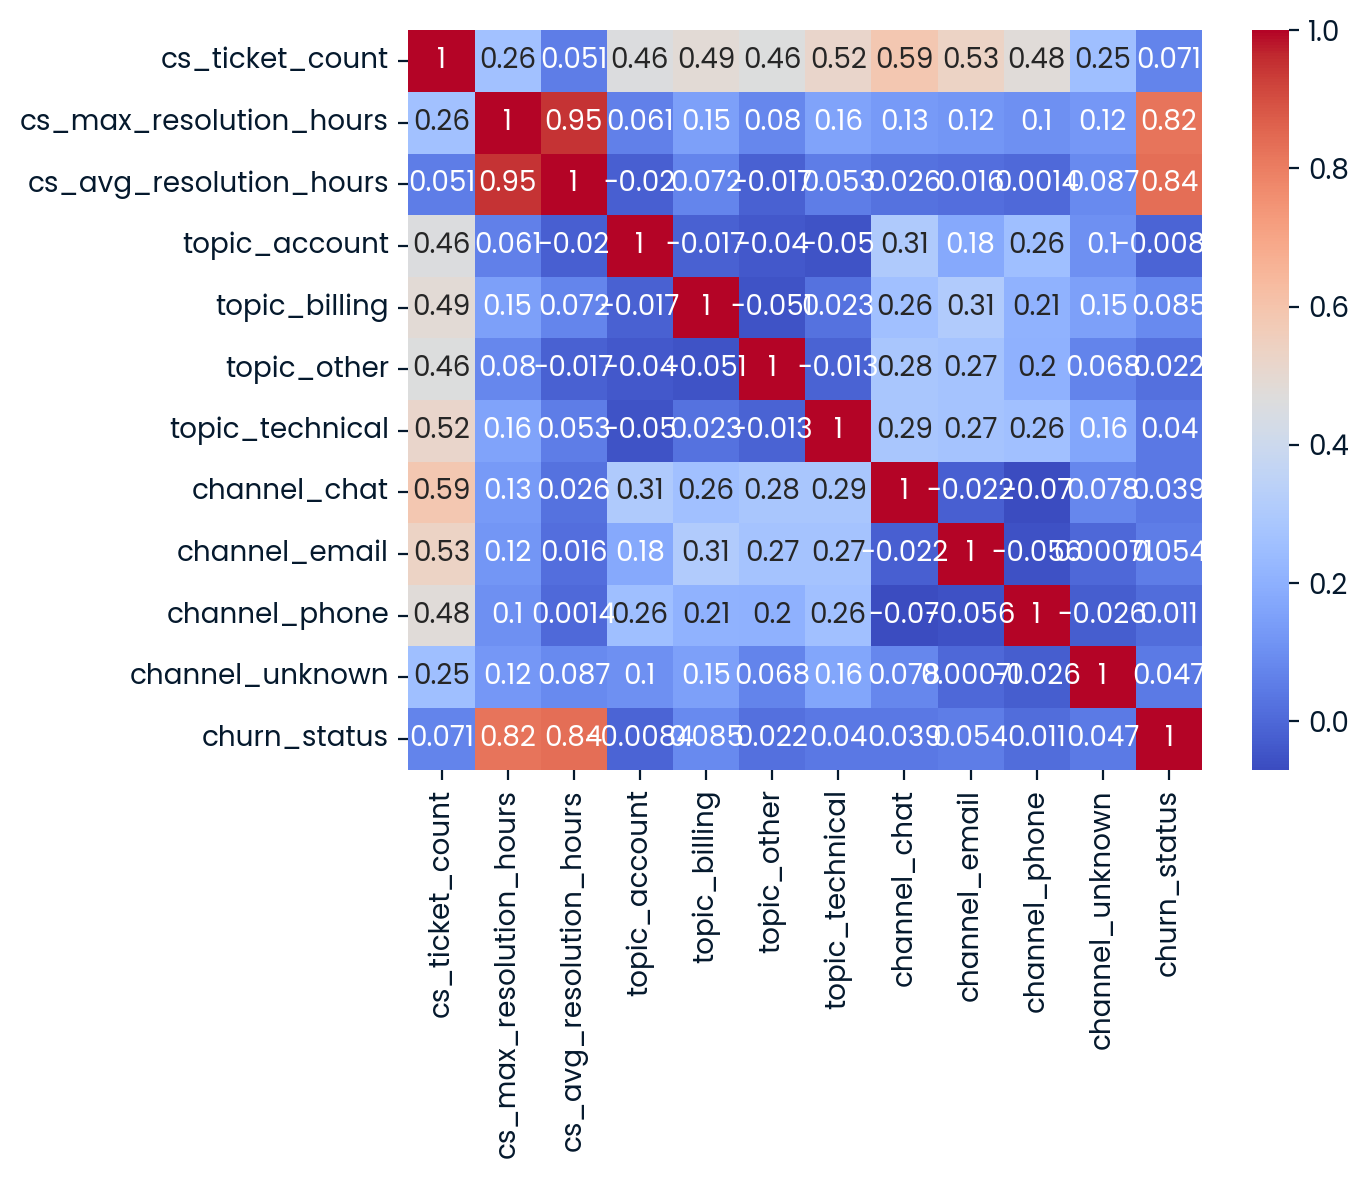

In [17]:
# correlation and heatmap
cs_corr = paying_cs[['plan', 'cs_ticket_count','cs_max_resolution_hours', 'cs_avg_resolution_hours', 'topic_account', 'topic_billing', 'topic_other', 'topic_technical',
       'channel_chat', 'channel_email', 'channel_phone', 'channel_unknown', 'churn_status']].corr()
sns.heatmap(cs_corr, annot = True, cmap = 'coolwarm')
plt.show()

In [18]:
print(act_df.groupby('plan')['plan_list_price'].describe())

            count        mean        std   min   25%    50%    75%    max
plan                                                                     
Basic       118.0   19.872881   5.914702  10.0  15.0   20.0   24.0   30.0
Enterprise   92.0  116.010870  20.532737  81.0  96.5  119.0  134.0  148.0
Free        105.0    0.000000   0.000000   0.0   0.0    0.0    0.0    0.0
Pro          85.0   53.741176  14.595460  32.0  42.0   53.0   64.0   80.0


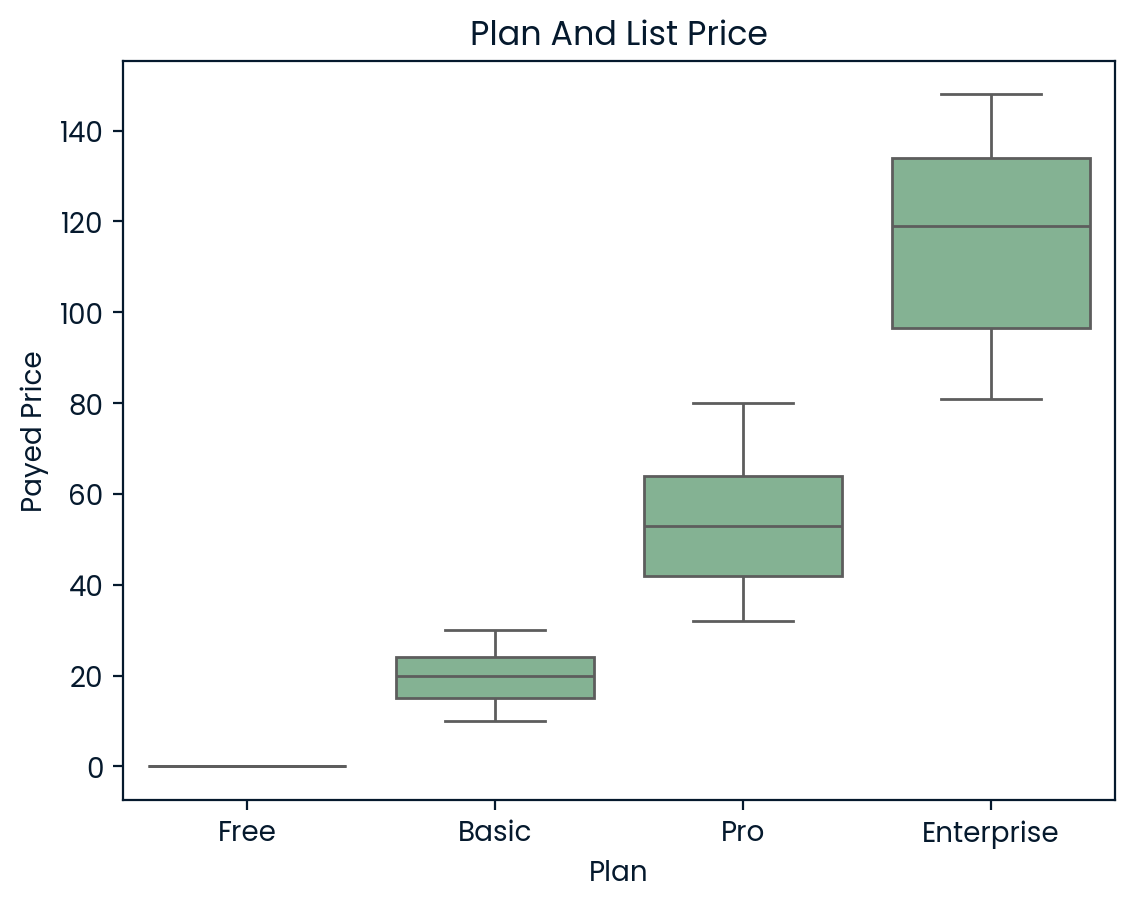

In [19]:
sns.boxplot(x = 'plan', y = 'plan_list_price', data = act_df
           , order = ['Free', 'Basic', 'Pro', 'Enterprise'])
plt.xlabel('Plan')
plt.ylabel('Payed Price')
plt.title('Plan And List Price')
plt.show()

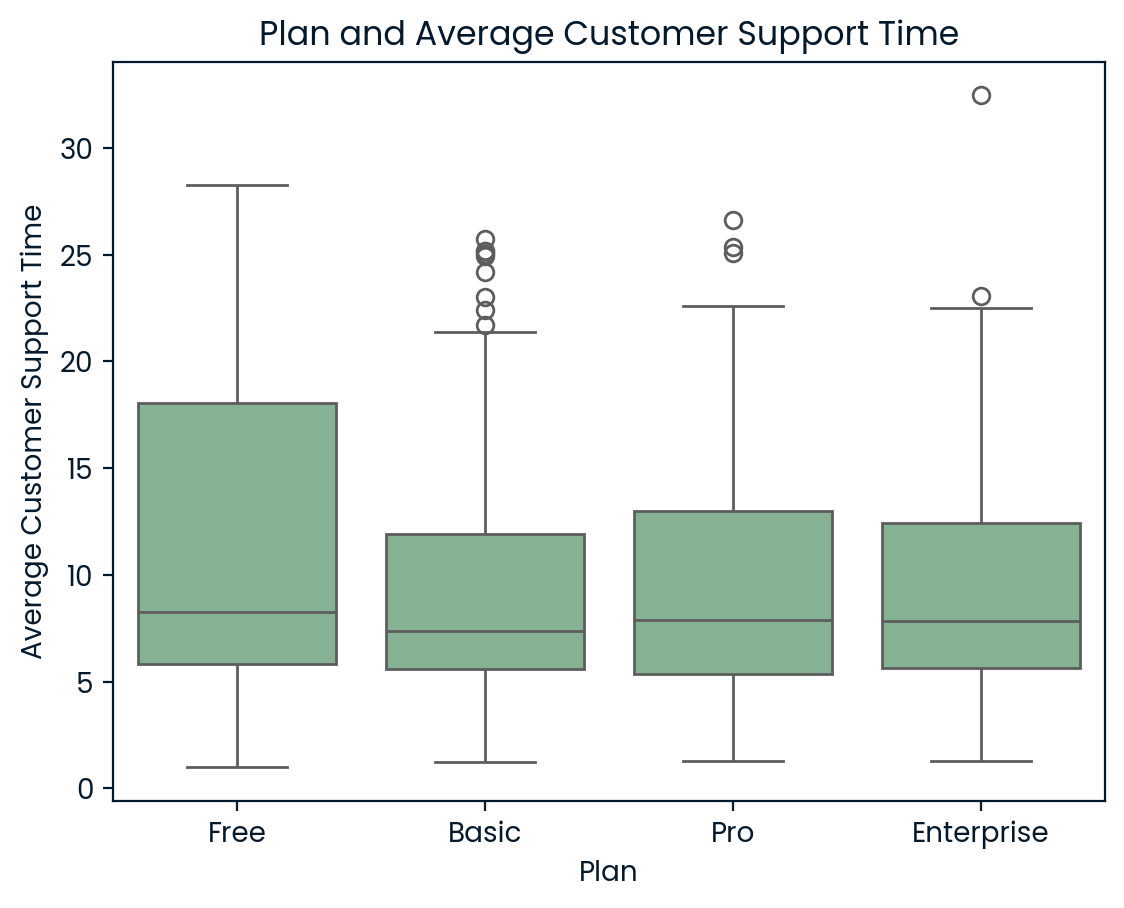

In [20]:
sns.boxplot(x = 'plan', y = 'cs_avg_resolution_hours', data = cs_df
           ,order = ['Free', 'Basic', 'Pro', 'Enterprise'] )
plt.xlabel('Plan')
plt.ylabel('Average Customer Support Time')
plt.title('Plan and Average Customer Support Time')
plt.show()

This first heatmap is showing correlation between things like plan type, activities, and how it correlates to churn status. The strongest indicator for churning is doing an activity with a relationship of -0.48. People who did any activity are less likely to churn! 

The second heatmap dives into correlation between customer support. The strongest correlations with churn_status are the average resolution for customer support with a .84 and the max time resolution with .82. Both of these are incredibly strong indicators that when someone has to wait longer on average or has a singular long wait time they are much more likely to quit.

The next 2 box-and-whisker plots are interesting to see in tandem. First is a look at the payed price per plan. As expected all free plans are at $0 and it increases from that point with no plan overlapping with another. We would expect customer support time to match this but it doesn't. The 2nd box plot we see that Free users take up more customer support time on average. 

This relationship between Price paid and average support time led me to what I believe is the most important KPI - Revenue Per Hour of Customer Support

In [21]:
# sanity check - total time CS per plan
cs_df['total_cs_time'] = cs_df['cs_avg_resolution_hours'] * cs_df['cs_ticket_count']

#sns.barplot(x = 'plan', y = 'total_cs_time', data = cs_df)
#plt.show()

In [22]:
paying_order = ['Basic', 'Pro', 'Enterprise']
# KPI - Support Time per Dollar
# calc full support time from avg and ticket numbers

# total time in Hours
paying_cs['total_support_hours'] = paying_cs['cs_avg_resolution_hours'] * paying_cs['cs_ticket_count']

# calc Rev per min of customer support
plan_rev_per_hour = paying_cs.groupby('plan').apply(
    lambda x: x['plan_list_price'].sum() / x['total_support_hours'].sum()
)

print(plan_rev_per_hour.loc[paying_order])

plan
Basic         0.902948
Pro           2.461976
Enterprise    5.850463
dtype: float64


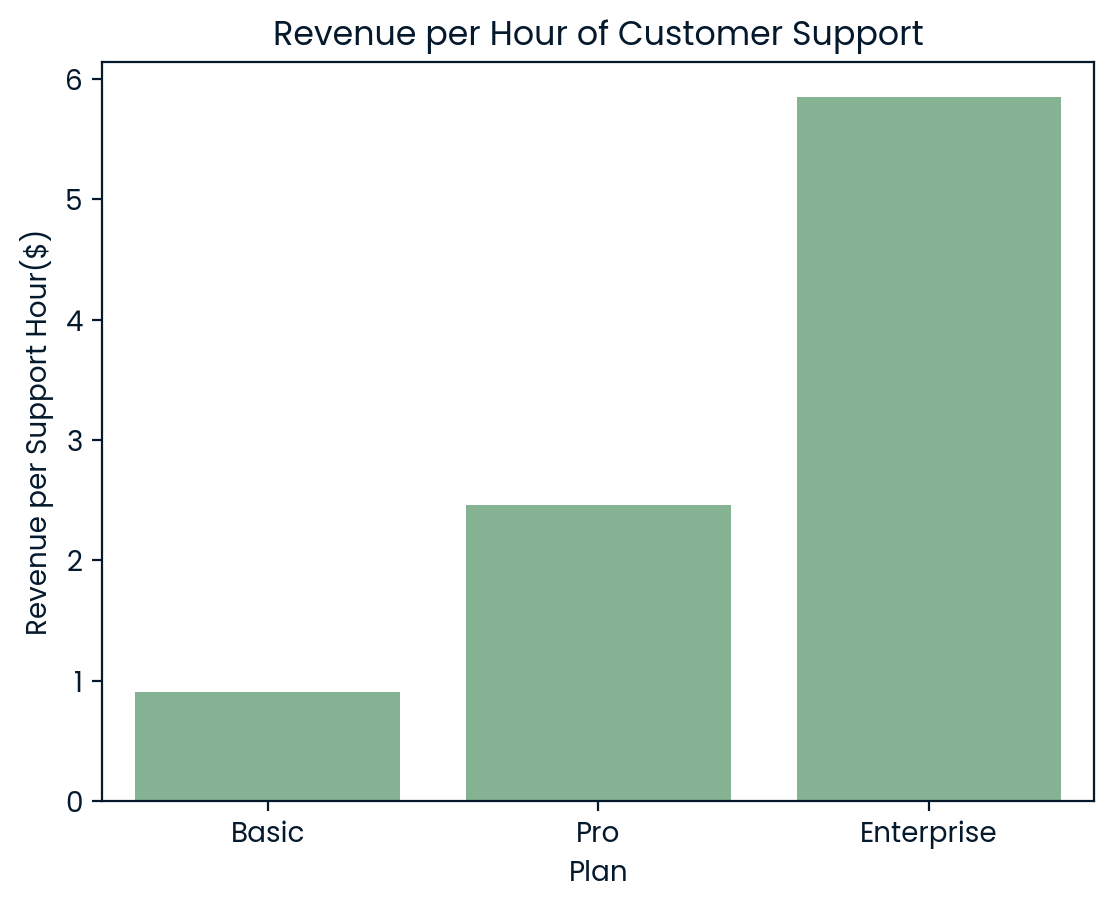

In [23]:
sns.barplot(
    x = plan_rev_per_hour.loc[paying_order].index,
    y = plan_rev_per_hour.loc[paying_order].values,
)
plt.title('Revenue per Hour of Customer Support')
plt.ylabel('Revenue per Support Hour($)')
plt.xlabel('Plan')
plt.show()

---
---
# Business Metric
Revenue per Hour of Customer Support. As the strongest indication of a customer churning we want to minimize the average ticket time and shrink the max customer support ticket time. However, we don't want to just do this across the board. We make more per hour of customer support time from Enterprise users than we do from Basic or Pro (or Free.)

Our initial values are here based on the current data:

Free: $0

Basic: $0.90

Pro: $2.46

Enterprise: $5.85

---
---
# Summary & Recommendations
Our strongest correlation with churn status is average customer resolution time in hours and max resolution time in hours, minimizing those will minimize our churn and increase revenue. 


One thing we could look at is how customer support ticket times influence and correlate with a member going from Free to a Basic or higher plan. If there is a strong sign that better customer support makes them more likely to pay then our plans should change. With that said, considering the cost of acquiring new users is rising I believe the best course of action is to shift customer support time towards Enterprise and Pro users to maximize our revenue per hour of Customer Support. 


Non-analysis Recommendations: Our emails on file are all placeholders! If we get legitimate emails on file they could be used as a strong retention tool. While this could be me not being able to see the actual emails I don't think it is: Nicole said she didn't think there was any anonymisation as part of the pipeline. 

In [24]:
'''
engagement, support activity, and plan type

two graphics showing single variables      - Done
one graphic showing two or more            - DONE
Description of findings                    - DONE

Definition of metric for business to monitor - DONE

'''

'\nengagement, support activity, and plan type\n\ntwo graphics showing single variables      - Done\none graphic showing two or more            - DONE\nDescription of findings                    - DONE\n\nDefinition of metric for business to monitor - DONE\n\n'

In [25]:
# // MISC WORK // #

In [26]:
# checking time of day churn

def time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'


qq = account_info.merge(cs, on = 'user_id', how = 'left')
qq['time_bucket'] = qq['ticket_time'].dt.hour.apply(time_of_day)
comparison = qq.groupby(['time_bucket', 'churn_status']).size().unstack(fill_value = 0)
print(comparison)

#qq.groupby('time_bucket')['churn_status'].mean().plot(kind = 'bar')
#plt.show()


churn_status    0   1
time_bucket          
Afternoon     125  71
Evening        99  35
Morning       172  80
Night         247  81


In [27]:
#checking correlation between weekend churn vs weekday churn

ddf = cs.merge(account_info, on = 'user_id', how = 'outer')

# to date_time
ddf['ticket_time'] = pd.to_datetime(ddf['ticket_time'])

ddf['is_weekend'] = (ddf['ticket_time'].dt.dayofweek >= 5).astype(int)  # 5=Saturday, 6=Sunday

weekend_churn = ddf[['is_weekend', 'churn_status']].corr()
#sns.heatmap(weekend_churn, annot = True, cmap = 'coolwarm')
#plt.show()


In [28]:
print(paying_act.columns)
participated_and_shared = paying_act[['share_workout', 'did_activity', 'churn_status']].copy()
participated_and_shared['both'] = ((participated_and_shared['share_workout'] == 1) & (participated_and_shared['did_activity'] == 1)).astype(int)

both_corr = participated_and_shared.corr()
#sns.heatmap(both_corr, annot = True, cmap = 'coolwarm')

Index(['user_id', 'state', 'plan', 'plan_list_price', 'churn_status',
       'total_activities', 'last_activity_time', 'days_since_activity',
       'read_article', 'share_workout', 'track_workout', 'watch_video',
       'did_activity', 'plan_num', 'plan_Basic', 'plan_Enterprise',
       'plan_Pro'],
      dtype='object')


In [29]:
print(
    paying_act[
        (paying_act['share_workout'] == 1) &
        (paying_act['did_activity'] == 0)
    ].shape
)

(0, 17)
